In [84]:
import pandas as pd

In [83]:
dataset_filename = "titanic_2.csv"

df = pd.read_csv(dataset_filename, index_col = 'PassengerId', dtype={'Name': pd.StringDtype(), 'Sex': pd.StringDtype(), 'Ticket':pd.StringDtype(), 'Cabin':pd.StringDtype(), 'Embarked':pd.StringDtype()} ) 
# trasformazione csv in data-frame, struttura tabellare 
# index_col indica quale colonna del dataframe predndere come indice colonna. 
# Altrimenti pandas l'aggiunge da solo
# metti il nome oppure il numnero della colonna
# aggiungiamo anche l'opzione che alcune colonne sono di tipo String

print(df.index)

print(df.columns)

print(df.shape)

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       882, 883, 884, 885, 886, 887, 888, 889, 890, 891],
      dtype='int64', name='PassengerId', length=891)
Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')
(891, 11)


In [3]:
## metodi

# primi sample di testa
df.head()
# ultimi sample di coda
df.tail()
# ultimi sample di coda (3 in totale)
df.tail(3)
# info sulla tipologia delle colonne
df.info()
# massimi valori
df.max()
# minimi valori
df.min()
# somma di tutti i sample numerici
df.sum(numeric_only = True)
# media di tutti i sample numerici
df.mean(numeric_only = True)
# descrizione statistica
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    string 
 3   Sex       891 non-null    string 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    string 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    string 
 10  Embarked  889 non-null    string 
dtypes: float64(2), int64(4), string(5)
memory usage: 83.5 KB


/tmp/ipykernel_15413/2254873211.py:12: FutureWarning: <class 'pandas.core.arrays.string_.StringArray'>._reduce will require a `keepdims` parameter in the future
  df.max()
/tmp/ipykernel_15413/2254873211.py:14: FutureWarning: <class 'pandas.core.arrays.string_.StringArray'>._reduce will require a `keepdims` parameter in the future
  df.min()


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# ordina in base ad una colonna specifica
df.sort_values('Fare', ascending = False)
# eliminiamo i sample nulli
df.dropna(subset='Age').sort_values('Age')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,<NA>,C
756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,<NA>,S
645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,<NA>,C
470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,<NA>,C
79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,<NA>,S
...,...,...,...,...,...,...,...,...,...,...,...
117,0,3,"Connors, Mr. Patrick",male,70.50,0,0,370369,7.7500,<NA>,Q
494,0,1,"Artagaveytia, Mr. Ramon",male,71.00,0,0,PC 17609,49.5042,<NA>,C
97,0,1,"Goldschmidt, Mr. George B",male,71.00,0,0,PC 17754,34.6542,A5,C


<Axes: ylabel='Frequency'>

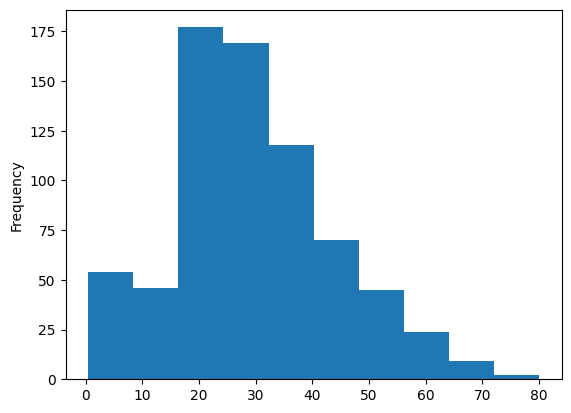

In [32]:
# oggetto di pandas: series -> monodimensionale
# df -> bidimensionale
df['Age']
# poi qui puoi aggiungere .min(), .max(), .describe(), .sort_values()
# .dropna(), plot()

# invece qui localizziamo una riga
df.loc[2]
# oppure un valore unico
df.loc[2, "Age"]


# plot
#df['Age'].plot()
df['Age'].plot(kind='hist')
#df['Pclass'].plot(kind='hist')

<Axes: ylabel='count'>

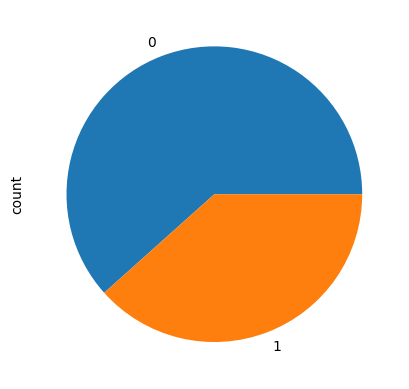

In [46]:
# value_counts: quanti sample hanno un dato valore
df['Age'].value_counts()
# cioè quante persone hanno una data età
# qui quante persone erano in prima, seconda e terza classe 
df['Pclass'].value_counts()
#df['Pclass'].value_counts().plot(kind='pie')

df['Survived'].value_counts().plot(kind='pie')


PassengerId
1      False
2      False
3      False
4      False
5      False
       ...  
887    False
888    False
889    False
890    False
891    False
Name: Age, Length: 891, dtype: bool

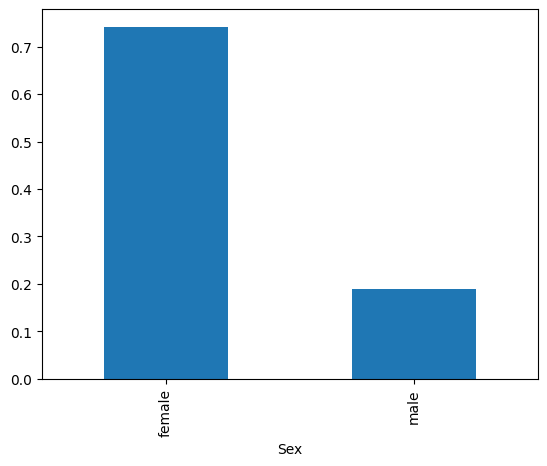

In [60]:
# gruppo di sample per ogni classe. un sottogruppi del dataframe
#df.groupby('Pclass')
df.groupby('Pclass').get_group(3) # prendi gruppo n#

# posso studiarne i dati statistici:
df.groupby('Pclass')["Survived"].mean()
#df.groupby('Pclass')["Survived"].mean().plot(kind='bar')

df.groupby('Sex')["Survived"].mean().plot(kind='bar')

In [65]:
# cerchiamo nella specie dell'età il sample che abbia come valore 80
#df["Age"] == 80 # condizione per filtrare il dataframe. vedi dopo:
df[ df["Age"] == 80]

df[ df["Age"] >= 60]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,<NA>,S
55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,<NA>,Q
171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S
253,0,1,"Stead, Mr. William Thomas",male,62.0,0,0,113514,26.5500,C87,S
276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S
281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,<NA>,Q
327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,<NA>,S


In [117]:

newfile = 'monthly_domestic_values_2025.csv'
df = pd.read_csv(newfile, sep='\t', dtype={"Category":pd.StringDtype(), "Area": pd.StringDtype()})

df.drop(["ProvidedValueCode", "MeasureItem", "Year", "MeasureItemID", "Representativity"],
        inplace=True, axis = 1)


# dati su un paese specifico
df = df.groupby('Area').get_group('IT')


#print(df.shape)
#print(df.index)
#print(df.head())
#print(df.columns)
#print(df.info() )
#print(df.describe())
#df["Category"]

df.mean(numeric_only = True)
df.sum(numeric_only = True)

Month              1537.000000
ProvidedValue    277362.593832
dtype: float64

In [126]:
df.groupby('Category')["ProvidedValue"].sum()

Category
Biomass                                  6021.949750
Consumption of Energy storage            1176.343000
Consumption of Fossil Hard coal             0.041750
Consumption of Hydro Pumped Storage      1783.445500
Consumption of Other renewable            498.008500
Consumption of Solar                        0.095750
Energy storage                           1294.090500
Export                                   2719.085922
Fossil Coal-derived gas                  4262.371250
Fossil Gas                             101492.029500
Fossil Hard coal                         3175.736750
Fossil Oil                                581.209750
Geothermal                               1303.973750
Hydro Pumped Storage                     2404.095750
Hydro Run-of-river and poundage         25395.535250
Hydro Water Reservoir                    4663.827750
Import                                  49831.243660
Other                                   15061.391500
Other renewable                      

<Axes: ylabel='ProvidedValue'>

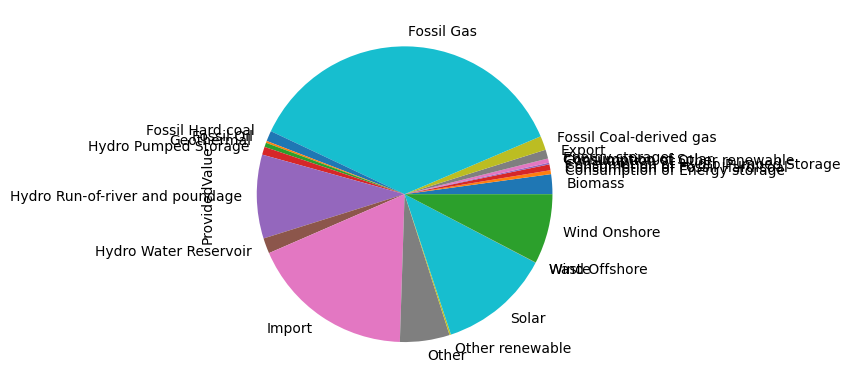

In [127]:
df.groupby('Category')["ProvidedValue"].sum().plot(kind='pie')